/var/folders/f9/38nkw6517lgf362dv55hy0xc0000gn/T/ipykernel_79433/1789391755.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['time'] = pd.to_datetime(df['time'])
/var/folders/f9/38nkw6517lgf362dv55hy0xc0000gn/T/ipykernel_79433/1789391755.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['time'] = pd.to_datetime(df['time'])
/var/folders/f9/38nkw6517lgf362dv55hy0xc0000gn/T/ipykernel_79433/1789391755.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['time'] = pd.to_datetime(df['time'])


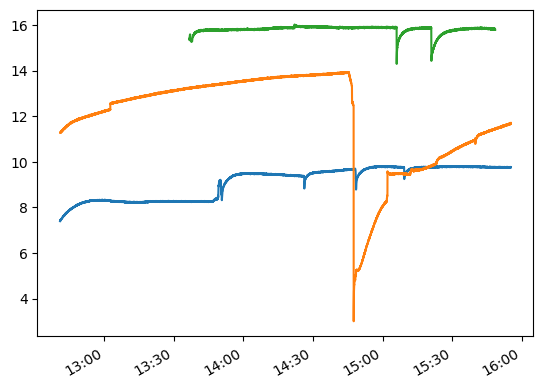

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from glob import glob
import matplotlib.dates as mdates

files = glob('*.csv')

# time,mixture cell P,reference cell P,mixture cell T,reference cell T
for file in files:
    df = pd.read_csv(file)
    df['time'] = pd.to_datetime(df['time'])
    plt.plot(df['time'], df['mixture cell P'])

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.gcf().autofmt_xdate()

In [2]:
df = pd.read_csv('station_1.csv')
df['time'] = pd.to_datetime(df['time'])

/var/folders/f9/38nkw6517lgf362dv55hy0xc0000gn/T/ipykernel_79433/1175830822.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['time'] = pd.to_datetime(df['time'])


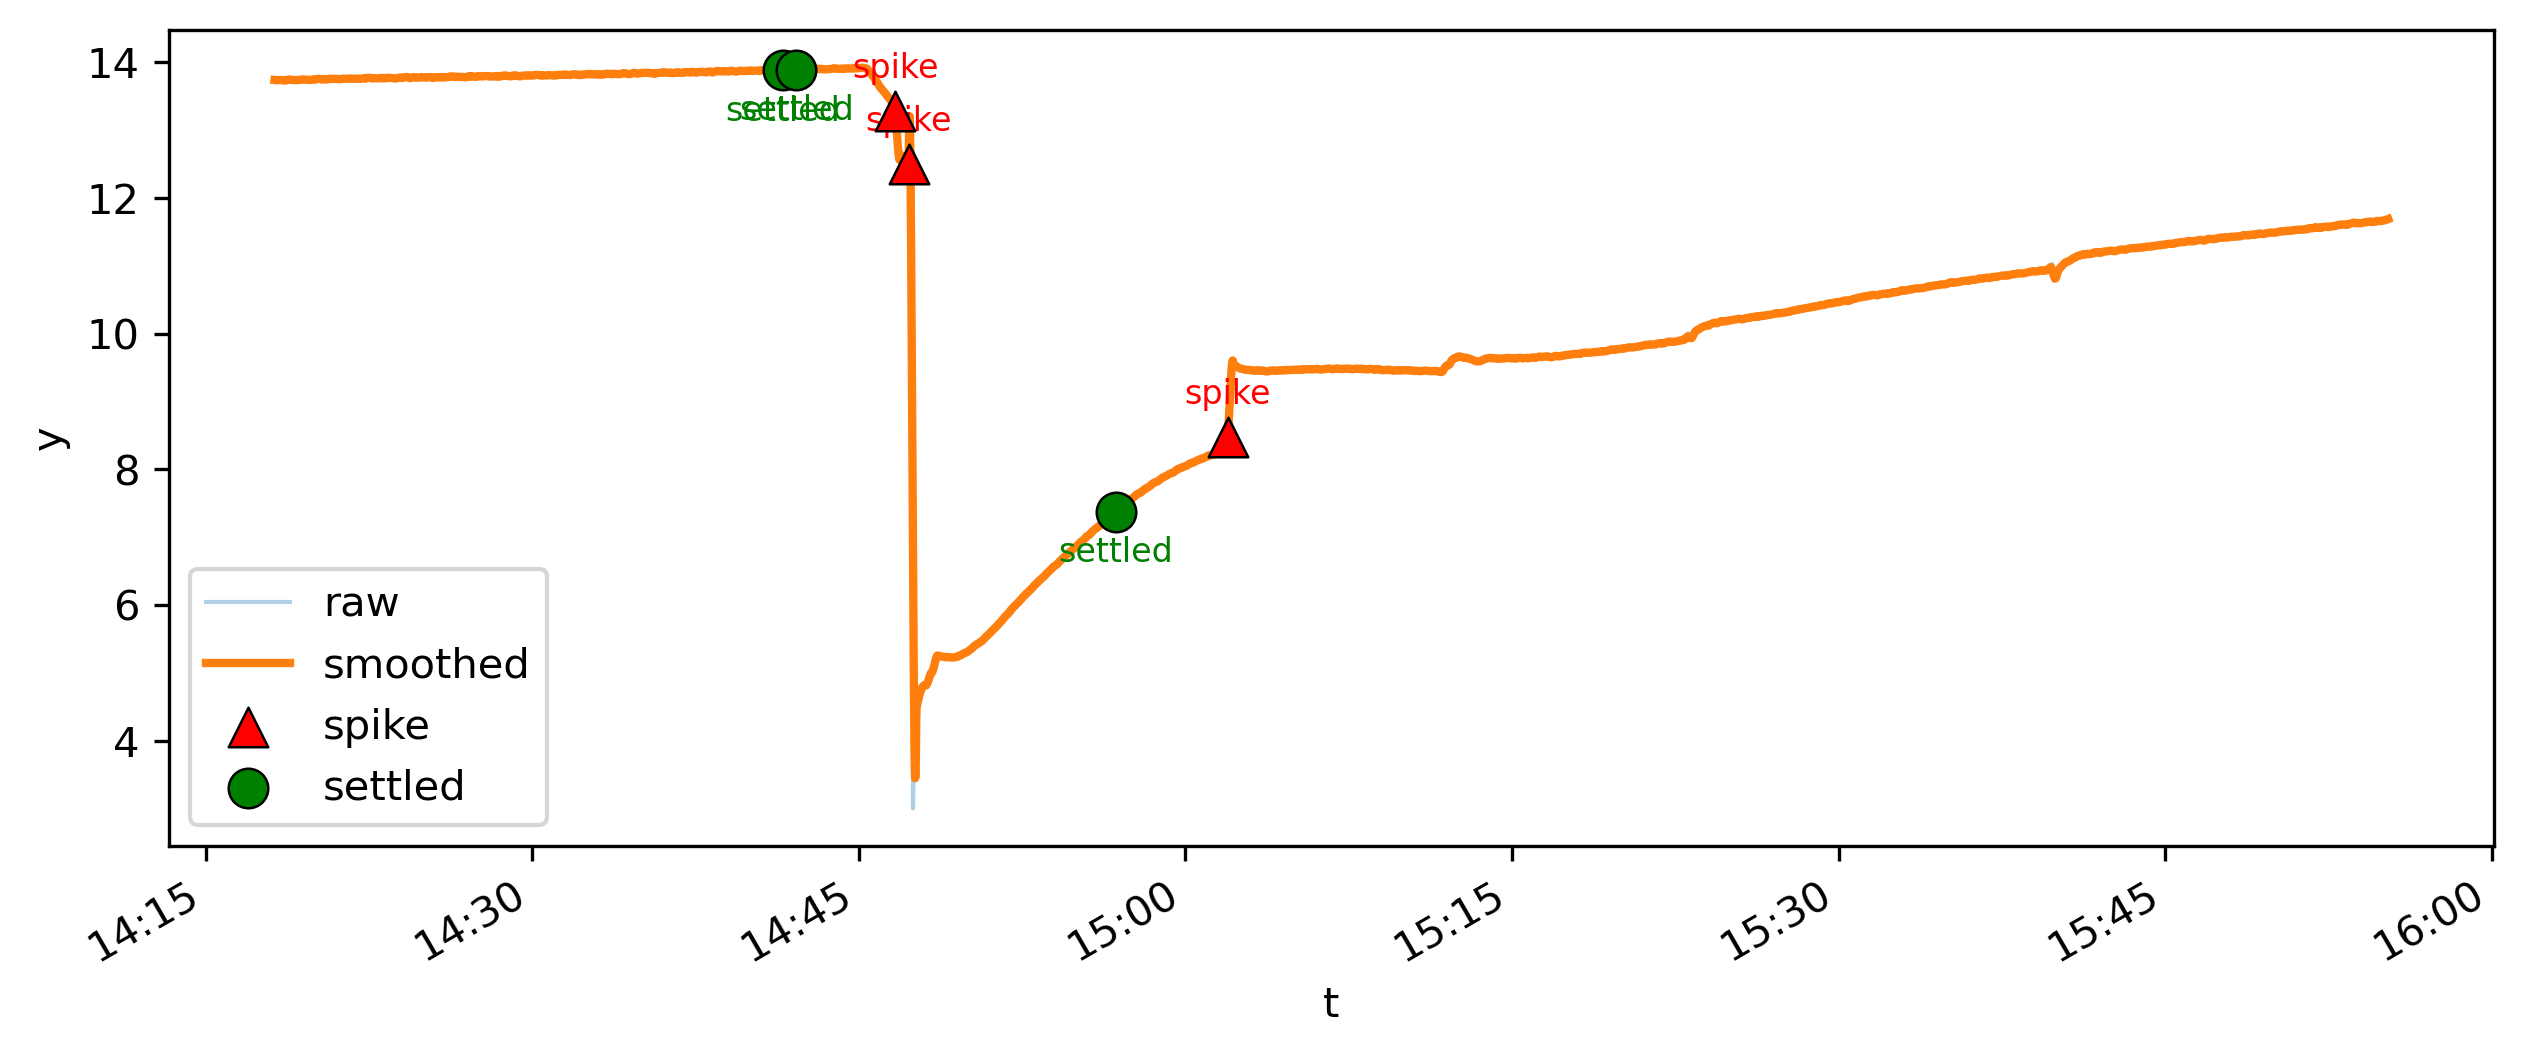

In [3]:
from scipy.signal import savgol_filter

def extract_settled_values(
    t,
    y,
    smooth_window=21,     
    polyorder=3,
    spike_thresh=0.05,    
):
    y_smooth = savgol_filter(y, smooth_window, polyorder)
    dy = np.gradient(y_smooth, t)
    spike_mask = np.abs(dy) > spike_thresh
    spike_indices = np.where(np.diff(spike_mask.astype(int)) == 1)[0] + 1

    settled_indices = []
    settled_values = []

    for s in spike_indices:
        t_spike = t[s]
        in_window = np.where((t >= t_spike - 980) & (t <= t_spike - 260))[0]  # 3–1 min before spike

        if in_window.size >= 100:
            chosen = in_window[-100:]  # take 100 closest points to 1 min before spike
        else:
            continue  
        settled_indices.append(chosen[len(chosen) // 2])  # representative index for plotting
        settled_values.append(np.mean(y_smooth[chosen]))
    return spike_indices, settled_indices, np.array(settled_values), y_smooth


t = df['time'].to_numpy()
y = df['mixture cell P'].to_numpy()
y_reference = df['reference cell P'].to_numpy()
t_sec = (t - t[0]) / np.timedelta64(1, "s")
spikes, settles, values, y_smooth = extract_settled_values(t_sec, y)

fig, ax = plt.subplots(figsize=(10, 4), dpi=300)
ax.plot(t[len(y)//2:], y[len(y)//2:], label="raw", alpha=0.35, linewidth=1)
ax.plot(t[len(y)//2:], y_smooth[len(y)//2:], label="smoothed", linewidth=2)
# ax.plot(t, y_reference, label="reference", linewidth=2)

if len(spikes) > 0:
    ax.scatter(
        t[spikes],
        y_smooth[spikes],
        color="red",
        s=90,
        marker="^",
        edgecolor="black",
        linewidth=0.6,
        zorder=5,
        label="spike",
    )
    for idx in spikes:
        ax.annotate(
            "spike",
            (t[idx], y_smooth[idx]),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=8,
            color="red",
        )

if len(settles) > 0:
    ax.scatter(
        t[settles],
        y_smooth[settles],
        color="green",
        s=90,
        marker="o",
        edgecolor="black",
        linewidth=0.6,
        zorder=5,
        label="settled",
    )
    for idx in settles:
        ax.annotate(
            "settled",
            (t[idx], y_smooth[idx]),
            textcoords="offset points",
            xytext=(0, -12),
            ha="center",
            fontsize=8,
            color="green",
        )

ax.legend()
ax.set_xlabel("t")
ax.set_ylabel("y")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gcf().autofmt_xdate()

In [4]:
window = 50  # points before/after each settled index

rows = []
n = len(y)

for s_idx in settles:
    start = max(0, s_idx - window)
    end = min(n, s_idx + window + 1)  # +1 because end is exclusive
    segment = y[start:end]

    rows.append(
        {
            "settled_index": int(s_idx),
            "time": t[s_idx],
            "start_idx": start,
            "end_idx": end - 1,
            "n_points": len(segment),
            "mean": float(np.mean(segment)),
            "std": float(np.std(segment, ddof=1)),
        }
    )

for s_idx in [len(y)-200]:
    start = max(0, s_idx - window)
    end = min(n, s_idx + window + 1)  # +1 because end is exclusive
    segment = y[start:end]

    rows.append(
        {
            "settled_index": int(s_idx),
            "time": t[s_idx],
            "start_idx": start,
            "end_idx": end - 1,
            "n_points": len(segment),
            "mean": float(np.mean(segment)),
            "std": float(np.std(segment, ddof=1)),
        }
    )


settled_stats = pd.DataFrame(rows)
settled_stats.to_clipboard(excel=True)
settled_stats

,settled_index,time,start_idx,end_idx,n_points,mean,std
0,7225,2026-04-23 14:41:31.093908,7175,7275,101,13.883147,0.013042
1,7262,2026-04-23 14:42:08.095730,7212,7312,101,13.886195,0.013290
2,8141,2026-04-23 14:56:47.305418,8091,8191,101,7.372808,0.130777
3,11448,2026-04-23 15:51:55.073385,11398,11498,101,11.557480,0.020991


In [5]:
settles

[7225, 7262, 8141]

In [6]:
y[:100].std()

0.05240142526089439

In [7]:
0.1+0.2

0.30000000000000004